In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
systems_cleaned = pd.read_csv('../../data/core/systems_cleaned.csv')

In [4]:
all_data_systems = systems_cleaned[
    systems_cleaned['has_current_data']
    & systems_cleaned['has_irradiance_data']
    & systems_cleaned['has_power_data']
    & systems_cleaned['has_temperature_data']
    & systems_cleaned['has_voltage_data']
]
all_data_ids = set(all_data_systems.system_id)

In [5]:
all_data_systems.head()

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_irradiance_data,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type
0,2,Residential 1a,"Lakewood, CO",America/Denver,39.7214,-105.0972,1675.0,2.912,Dfb,12,...,True,False,True,True,True,True,True,True,multi-Si,multicrystalline_Si
1,3,Residential 1b,"Lakewood, CO",America/Denver,39.7214,-105.0972,1675.0,2.720,Dfb,12,...,True,False,True,True,True,True,True,True,amorphous si,thin_film
2,4,NREL x-Si -1,"Golden, CO",7,39.7406,-105.1774,1795.3,1.000,BSk,12,...,True,True,True,True,True,True,True,True,mono-Si,monocrystalline_Si
3,10,NREL CIS -1,"Golden, CO",7,39.7404,-105.1774,1792.8,1.120,BSk,12,...,True,True,True,True,True,True,True,True,cis family thin-film,thin_film
4,33,Silicor Materials,"Golden, CO",7,39.7404,-105.1772,1794.0,2.400,BSk,12,...,True,True,True,True,True,True,True,True,Unknown,unknown


## Parquet systems -- metadata survey.

In [7]:
metrics_dir = Path("../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

In [40]:
my_system_ids = list(all_data_ids.intersection(metrics_id_set))
my_system_ids.sort()
num_ids = len(my_system_ids)
num_ids

39

In [41]:
j = 2
system_id = my_system_ids[j]
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1711,4,314,dc_power,DC power,W,W,1.0,0.0,,avg,None,NaN,,dc_power__314
1712,4,315,ac_power,AC power,W,W,1.0,0.0,,avg,None,NaN,,ac_power__315
1713,4,319,ac_current,AC current,A,A,1.0,0.0,,avg,None,NaN,,ac_current__319
1714,4,327,power_factor,AC other,na,na,1.0,0.0,,avg,None,NaN,,power_factor__327
1715,4,318,ac_voltage,AC voltage,V,V,1.0,0.0,,avg,None,NaN,,ac_voltage__318
1716,4,317,dc_pos_current,DC current,A,A,1.0,0.0,,avg,None,NaN,,dc_pos_current__317
1717,4,326,das_battery_voltage,DC voltage battery,V,V,1.0,0.0,,avg,None,NaN,,das_battery_voltage__326
1718,4,313,poa_irradiance,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,None,NaN,,poa_irradiance__313
1719,4,320,ambient_temp,Temperature ambient,C,C,1.0,0.0,,avg,None,NaN,,ambient_temp__320
1720,4,321,module_temp_1,Temperature module,C,C,1.0,0.0,,avg,None,NaN,,module_temp_1__321


Ignore power-factor for now, re-incorporate if there is a problem.

In [42]:
my_metrics = [315, 313, 321, 322, 323]
# grab sensor_name data of these metrics for later
relevant_rows_metrics_pruned = relevant_rows_metrics.loc[
    relevant_rows_metrics.loc[:, 'metric_id'].isin(my_metrics) #keep only rows whose metric_id is in my_metrics
]
# to keep the same sorting, re-name metric id's as follows.
metric_ids = tuple(relevant_rows_metrics_pruned.metric_id)
metric_names = tuple(relevant_rows_metrics_pruned.sensor_name)

In [43]:
access_system_dir = Path(f'../../../data_ds_project/systems/parquet/{system_id}/')
current_pq = pq.ParquetDataset(access_system_dir,
                               filters= [
                                   ('metric_id', 'in', my_metrics) #in particular, only look a the my_metric_id's
                               ])
current_df = current_pq.read().to_pandas()

In [44]:
current_df

,measured_on,utc_measured_on,metric_id,value
0,2007-08-26 00:00:00,NaT,321,21.588000
1,2007-08-26 00:15:00,NaT,315,-0.029000
2,2007-08-26 00:15:00,NaT,313,13.000000
3,2007-08-26 00:30:00,NaT,313,13.000000
4,2007-08-26 00:45:00,NaT,315,-0.020000
...,...,...,...,...
31048253,2023-02-28 23:50:00,2023-03-01 06:50:00,313,-2.907071
31048254,2023-02-28 23:50:00,2023-03-01 06:50:00,315,2.699289
31048255,2023-02-28 23:50:00,2023-03-01 06:50:00,321,-6.008129
31048256,2023-02-28 23:50:00,2023-03-01 06:50:00,322,-5.768328


In [45]:
# debug of widening rule
current_df = current_df.drop_duplicates()
current_df[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2020-07-17 00:29:00  313          3
2020-07-18 00:18:00  323          3
2020-07-17 01:05:00  313          3
                     315          3
2020-07-18 00:19:00  313          3
                                 ..
2023-02-28 23:59:00  313          1
                     315          1
                     321          1
                     322          1
2007-08-26 01:00:00  321          1
Name: count, Length: 30958735, dtype: int64

In [46]:
first_example = current_df[
    current_df['measured_on'] == np.datetime64("2020-07-17 00:29:00")
]

In [47]:
first_example.sort_values(by='metric_id')

,measured_on,utc_measured_on,metric_id,value
24615762,2020-07-17 00:29:00,2020-07-17 07:29:00,313,-2.880187
24621575,2020-07-17 00:29:00,2020-07-17 07:29:00,313,-2.700178
24621576,2020-07-17 00:29:00,2020-07-17 07:29:00,313,-2.700178
24614563,2020-07-17 00:29:00,2020-07-17 07:29:00,315,2.992020
24625086,2020-07-17 00:29:00,2020-07-17 07:29:00,315,2.931852
24615763,2020-07-17 00:29:00,2020-07-17 07:29:00,321,21.952720
24621577,2020-07-17 00:29:00,2020-07-17 07:29:00,321,21.099370
24615760,2020-07-17 00:29:00,2020-07-17 07:29:00,322,21.105590
24625090,2020-07-17 00:29:00,2020-07-17 07:29:00,322,21.981700
24614564,2020-07-17 00:29:00,2020-07-17 07:29:00,323,22.119670


OK, there's genuinely 2 data points registered at this time, and there is no way to know which one(s) are accurate.
For preliminary data, just average it.
Trick taken from https://stackoverflow.com/questions/33445009/pandas-new-column-from-groupby-averages

In [48]:
current_df.loc[:, 'mean_value'] = current_df.groupby(['measured_on', 'metric_id'])['value'].transform('mean')

C:\Users\ch83b\AppData\Local\Temp\ipykernel_92212\4226163565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_df.loc[:, 'mean_value'] = current_df.groupby(['measured_on', 'metric_id'])['value'].transform('mean')


In [49]:
first_example_again = current_df[
    current_df['measured_on'] == np.datetime64("2020-07-17 01:03:00")
]

In [51]:
first_example_again.sort_values(by='metric_id')

,measured_on,utc_measured_on,metric_id,value,mean_value
24614691,2020-07-17 01:03:00,2020-07-17 08:03:00,313,-3.600163,-3.420205
24625213,2020-07-17 01:03:00,2020-07-17 08:03:00,313,-3.240247,-3.420205
24621703,2020-07-17 01:03:00,2020-07-17 08:03:00,315,2.936126,2.979233
24615981,2020-07-17 01:03:00,2020-07-17 08:03:00,315,3.022341,2.979233
24625215,2020-07-17 01:03:00,2020-07-17 08:03:00,321,21.162660,21.172425
24614692,2020-07-17 01:03:00,2020-07-17 08:03:00,321,21.182190,21.172425
24614689,2020-07-17 01:03:00,2020-07-17 08:03:00,322,21.162660,21.174500
24621707,2020-07-17 01:03:00,2020-07-17 08:03:00,322,21.186340,21.174500
24621705,2020-07-17 01:03:00,2020-07-17 08:03:00,323,21.395510,21.386270
24615982,2020-07-17 01:03:00,2020-07-17 08:03:00,323,21.377030,21.386270


Sadly, now still duplicates, so to get my shortcut, I have to *drop* the original value and then drop-duplicates again.

In [52]:
current_df = current_df.drop(columns='value')
current_df = current_df.drop_duplicates()

In [53]:
current_df[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2019-03-19 23:51:00  313          2
                     315          2
                     321          2
                     322          2
                     323          2
                                 ..
2023-02-28 23:59:00  313          1
                     315          1
                     321          1
                     322          1
2007-08-26 01:00:00  321          1
Name: count, Length: 30958735, dtype: int64

In [54]:
second_example = current_df[
    current_df['measured_on'] == np.datetime64("2019-03-19 23:51:00")
]

In [55]:
second_example.sort_values(by='metric_id')

,measured_on,utc_measured_on,metric_id,mean_value
21525696,2019-03-19 23:51:00,2019-03-20 05:51:00,313,-2.946198
21525811,2019-03-19 23:51:00,2019-03-20 06:51:00,313,-2.946198
21525812,2019-03-19 23:51:00,2019-03-20 05:51:00,315,2.772920
21525810,2019-03-19 23:51:00,2019-03-20 06:51:00,315,2.772920
21525695,2019-03-19 23:51:00,2019-03-20 05:51:00,321,-5.133130
21525694,2019-03-19 23:51:00,2019-03-20 06:51:00,321,-5.133130
21525753,2019-03-19 23:51:00,2019-03-20 06:51:00,322,-5.070386
21525752,2019-03-19 23:51:00,2019-03-20 05:51:00,322,-5.070386
21525754,2019-03-19 23:51:00,2019-03-20 05:51:00,323,-4.572429
21525639,2019-03-19 23:51:00,2019-03-20 06:51:00,323,-4.572429


Disagreements in utc_measured_on!  Must drop this for now.

In [56]:
current_df = current_df.drop(columns='utc_measured_on')


In [57]:
current_df = current_df.drop_duplicates()

In [58]:
current_df[['measured_on', 'metric_id']].value_counts()

measured_on          metric_id
2023-02-28 23:59:00  323          1
2007-08-26 00:00:00  313          1
                     315          1
                     321          1
2007-08-26 00:15:00  313          1
                                 ..
2007-08-26 01:30:00  315          1
                     313          1
2007-08-26 01:15:00  321          1
                     315          1
                     313          1
Name: count, Length: 30958735, dtype: int64

In [59]:
# to make calculations, 'widen' the frame!
# but drop duplicates to make this possible.
current_df_wide = current_df.pivot(
    index = 'measured_on', 
    columns = 'metric_id',
    values = 'mean_value'
)
current_df_wide.head()

metric_id,313,315,321,322,323
measured_on,,,,,
2007-08-26 00:00:00,14.0,-0.006,21.588,NaN,NaN
2007-08-26 00:15:00,13.0,-0.029,21.972,NaN,NaN
2007-08-26 00:30:00,13.0,-0.029,21.920,NaN,NaN
2007-08-26 00:45:00,12.0,-0.020,22.013,NaN,NaN
2007-08-26 01:00:00,13.0,-0.021,21.414,NaN,NaN


In [60]:
metric_names

('ac_power',
 'poa_irradiance',
 'module_temp_1',
 'module_temp_2',
 'module_temp_3')

In [61]:
metric_ids

(315, 313, 321, 322, 323)

In [62]:
changeup_dict = {
    metric_ids[j]: metric_names[j] for j in range(len(my_metrics))
}
current_df_wide = current_df_wide.rename(
    columns=changeup_dict
)

In [63]:
current_df_wide.head()

metric_id,poa_irradiance,ac_power,module_temp_1,module_temp_2,module_temp_3
measured_on,,,,,
2007-08-26 00:00:00,14.0,-0.006,21.588,NaN,NaN
2007-08-26 00:15:00,13.0,-0.029,21.972,NaN,NaN
2007-08-26 00:30:00,13.0,-0.029,21.920,NaN,NaN
2007-08-26 00:45:00,12.0,-0.020,22.013,NaN,NaN
2007-08-26 01:00:00,13.0,-0.021,21.414,NaN,NaN


In [67]:
current_df_wide.describe()

metric_id,poa_irradiance,ac_power,module_temp_1,module_temp_2,module_temp_3
count,6.102499e+06,6.346379e+06,6.329823e+06,6.068769e+06,6.111265e+06
mean,1.665859e+02,1.612238e+02,-6.424549e+02,-9.606870e+02,-7.363831e+02
std,7.863137e+02,2.678272e+02,2.200640e+03,2.621603e+03,2.337769e+03
min,-7.999000e+03,-1.786679e+03,-7.999000e+03,-7.999000e+03,-7.999000e+03
25%,-2.882002e+00,2.858690e+00,7.538914e-01,-6.167883e-01,4.235946e-01
50%,2.012375e+00,3.149260e+00,1.214549e+01,1.130371e+01,1.199957e+01
75%,3.607549e+02,2.186033e+02,2.401557e+01,2.341397e+01,2.405020e+01
max,3.624723e+03,2.101946e+03,1.770000e+03,2.011000e+03,2.630000e+02


In [70]:
current_df_wide['module_temp_1'].value_counts()

module_temp_1
-7999.000000    519860
 0.000000         1160
 1770.000000       384
 0.001000          197
 8.976000           27
                 ...  
-7.140312            1
-6.991722            1
-6.711915            1
-6.451227            1
-6.367945            1
Name: count, Length: 3693016, dtype: int64

In [82]:
# trim zero values before graphing
current_df_trimmed = current_df_wide[
    (current_df_wide['ac_power'] > 5)
    & (current_df_wide['poa_irradiance'] > 100)
    & (current_df_wide['module_temp_1'] > -7000)
    & (current_df_wide['module_temp_2'] > -7000)
    & (current_df_wide['module_temp_3'] > -7000)
]

In [83]:
num_terms = current_df_trimmed.shape[0]

In [84]:
num_terms

1938899

In [85]:
num_terms*0.25

484724.75

In [74]:
current_df_trimmed.head()

metric_id,poa_irradiance,ac_power,module_temp_1,module_temp_2,module_temp_3
measured_on,,,,,
2010-11-19 12:41:00,585.4984,492.0740,28.2468,25.3577,28.4073
2010-11-19 12:42:00,417.0740,348.9642,27.2324,25.0851,27.1505
2010-11-19 12:43:00,439.8155,375.4588,26.5001,24.4853,26.4653
2010-11-19 12:44:00,497.0614,428.0398,26.1980,24.3123,26.0483
2010-11-19 12:45:00,479.0838,409.9684,25.9042,24.1683,25.6510


In [73]:
current_df_trimmed.describe()

metric_id,poa_irradiance,ac_power,module_temp_1,module_temp_2,module_temp_3
count,2.363268e+06,2.363268e+06,2.363268e+06,2.363268e+06,2.363268e+06
mean,4.997529e+02,3.824495e+02,2.673057e+01,2.672591e+01,2.770254e+01
std,3.679894e+02,2.956209e+02,1.422920e+01,1.406253e+01,1.491310e+01
min,-3.148738e+03,5.000140e+00,-2.548480e+01,-2.557950e+01,-2.505780e+01
25%,1.529595e+02,9.480820e+01,1.640535e+01,1.652159e+01,1.665609e+01
50%,4.355198e+02,3.338608e+02,2.704109e+01,2.705170e+01,2.770287e+01
75%,8.493807e+02,6.691370e+02,3.737037e+01,3.720347e+01,3.892447e+01
max,3.337168e+03,2.101946e+03,6.608390e+01,6.680791e+01,6.735420e+01


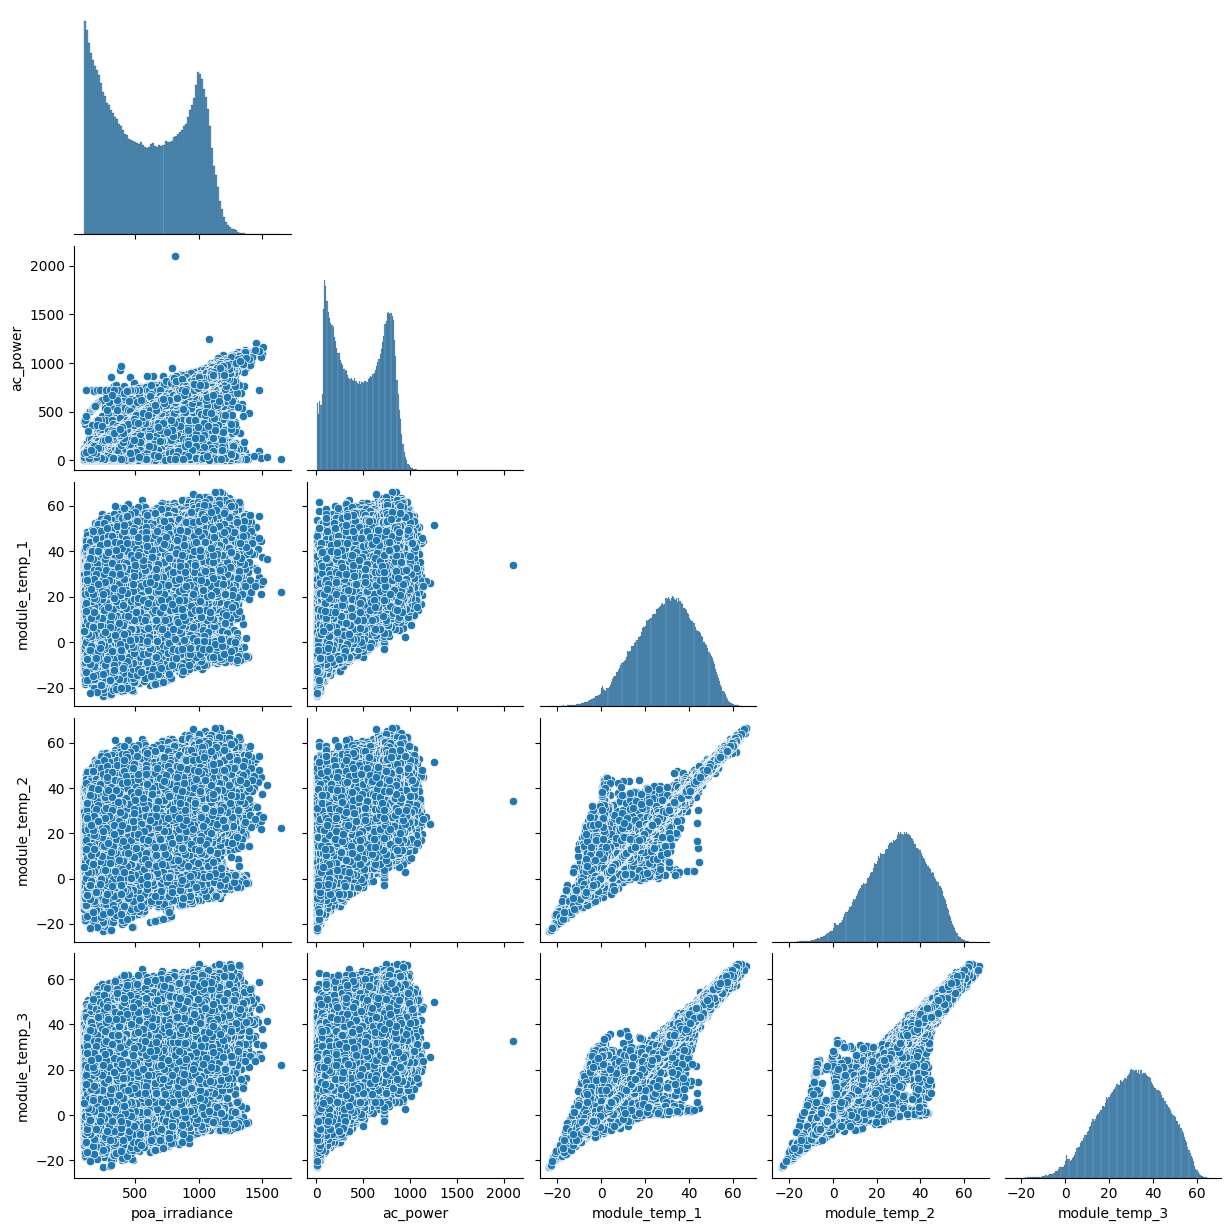

In [86]:
sns.pairplot(
    data=current_df_trimmed.sample(n=500000),
    corner=True
)

Clearly, for system 4, P=IV trend is obtained, but computed power may be somewhat higher!

In [35]:
current_df_wide['abs_power_diff'] = np.abs(current_df_wide['ac_power'] - current_df_wide['power_manual'])
# remake trimmed version
current_df_trimmed = current_df_wide[
    (current_df_wide['ac_power'] > 0.5)
    & (current_df_wide['ac_current'] > 0.5)
    & (current_df_wide['ac_voltage'] > 0.5)
]

In [36]:
current_df_trimmed['abs_power_diff'].describe()

count    2.715925e+06
mean     4.000795e+01
std      5.999898e+03
min      7.466814e-03
25%      1.587618e+01
50%      2.018221e+01
75%      2.890311e+01
max      9.887200e+06
Name: abs_power_diff, dtype: float64

So in 75% of cases, we are less than 29 Watts off, and the mean diff is 40 watts.

We say 0.5 KW (500 W) is a significant difference

In [37]:
current_df_trimmed_sig_diff = current_df_trimmed[current_df_trimmed['abs_power_diff'] >= 500]

In [38]:
current_df_trimmed_sig_diff.describe()

metric_id,ac_power,ac_voltage,ac_current,power_manual,abs_power_diff
count,27912.000000,2.791200e+04,27912.000000,2.791200e+04,2.791200e+04
mean,34.836998,1.657479e+02,5.104540,9.763313e+02,9.414943e+02
std,36.750065,7.319776e+03,0.632844,5.917673e+04,5.917691e+04
min,0.501000,6.480400e+01,1.913900,5.040015e+02,5.000099e+02
25%,11.224250,1.214560e+02,4.976000,6.059900e+02,5.527815e+02
50%,26.670500,1.220130e+02,5.121000,6.228639e+02,5.961663e+02
75%,53.765000,1.224850e+02,5.194000,6.336851e+02,6.202276e+02
max,1803.321000,1.223028e+06,39.429000,9.887203e+06,9.887200e+06


In [39]:
current_df_trimmed_sig_diff.shape

(27912, 5)

Plenty of issues.